# Getting started

Welcome! This notebook runs on your computer and talks to the **Rust simulation kernel**.
You do **not** need to build the browser Studio or WASM — just follow the steps below.

## What you need

| Tool | Why | Install |
| --- | --- | --- |
| **Git** | Clone this repository | [git-scm.com](https://git-scm.com/) |
| **uv** | Fast Python package manager | [docs.astral.sh/uv](https://docs.astral.sh/uv/getting-started/installation/) |
| **Rust (rustup)** | Build the native `_core` extension via maturin | [rustup.rs](https://rustup.rs/) |

## Step-by-step setup

### 1. Clone the repository

```bash
git clone https://github.com/OliverEvans96/blueberries-voi.git
cd blueberries-voi
```

### 2. Install Python dependencies

From the repository root:

```bash
uv sync --python 3.11
```

### 3. Build the Rust extension

Still from the repo root (first build may take a few minutes):

```bash
uv run --python 3.11 maturin develop --release -m crates/voi_py/Cargo.toml
```

### 4. Start Jupyter Lab

```bash
export BLUEBERRIES_VOI_BACKEND=rust
uv run jupyter lab notebooks/
```

Open `19_build_your_own_controller.ipynb` and run the cells in order.
The first code cell should print **`Rust backend ready.`**

### Optional: register a Jupyter kernel

If your IDE's kernel picker does not see the project environment:

```bash
uv run --python 3.11 python -m ipykernel install --user --name blueberries-voi
```

Then select **blueberries-voi** as the notebook kernel.

## Troubleshooting

| Problem | What to try |
| --- | --- |
| **`uv: command not found`** | Install uv (see table above), then open a new terminal |
| **`rustc` / `cargo` not found** | Install Rust via rustup, then open a new terminal |
| **Import error for `blueberries_voi._core`** | Re-run Step 3 (`maturin develop …`) from the repo root |
| **Notebook falls back to Python backend** | Set `export BLUEBERRIES_VOI_BACKEND=rust` before starting Jupyter |
| **Training or benchmarks feel slow** | Lower `N_PARTICLES` or `TRAIN_EPISODES` in the parameters cell; the first Rust build is also slow |


# Build your own controller

This notebook teaches **Option A**: a Python controller drives the production
`EngineSession` (Rust kernel) in a simple loop:

1. Read belief + pipeline from `session.snapshot()`
2. Choose an order with your `controller.order(ctx)`
3. Advance physics + filter with `session.step(order_qty)`

We compare teachable controllers against production **damped survival-weighted**
ordering via `session.act(policy="damped_sw")`.

## What your controller sees (`ControllerContext`)

Each `order(ctx)` call is a **pre-step** view: filter posterior only, never
simulator ground truth. Observation channels change filter *values* inside
`ctx.belief` (same shape), not the API.

| Field | Meaning |
| --- | --- |
| `ctx.belief.freshness_grid` | Freshness knot values $f_k$ on the wire |
| `ctx.belief.lot_marginals` | Per-lot posterior $p_{\ell,k}$ over the grid |
| `ctx.posterior_units` | Optional summed belief mass (not truth inventory) |
| `ctx.demand_forecast` | Committed demand: `scale_mu`, `dow_means` |
| `ctx.inbound_pipeline` | Orders placed, not yet arrived `{arrival_day: units}` |
| `ctx.order_schedule` | Delivery weekdays + lead time |
| `ctx.can_order_today` | False on non-order days → return 0 |
| `ctx.store_economics` | Studio money knobs (`sell_price`, costs) — session config |
| `ctx.episode_day`, `ctx.step_seq` | Calendar day index and monotonic step counter |

**Not in `ctx`:** ground-truth lots, controller budgets, raw observations.
Profit scoring uses Studio P&L via `store_economics` after each step.


Import the library helpers and confirm the Rust backend is available.

In [1]:
%matplotlib inline

from __future__ import annotations

import os
import random
from collections import defaultdict

os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")

import matplotlib.pyplot as plt
from statistics import mean
from tqdm.auto import tqdm

from blueberries_voi.backend import rust_available, warn_fallback_once
from blueberries_voi.controller.session_loop import (
    ControllerContext,
    ControllerProtocol,
    ControllerStepLog,
    EpisodeTotals,
    LearningController,
    default_session_config,
    episode_totals_from_logs,
    run_controller_session,
)
from blueberries_voi.filter.types import ObsChannels
from blueberries_voi.model import ModelParams
from blueberries_voi.sim.bakeoff_damped_sw import protection_demand_quantile
from blueberries_voi.sim.case_round import case_round
from blueberries_voi.sim.profit import StoreEconomics
from blueberries_voi.sim.shipments import smoke_cool_shipments
from blueberries_voi.simulator import EngineSession

plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3})

warn_fallback_once()
if not rust_available():
    raise RuntimeError(
        "Rust backend unavailable. From repo root run:\n"
        "  uv run --python 3.11 maturin develop --release -m crates/voi_py/Cargo.toml\n"
        "then: export BLUEBERRIES_VOI_BACKEND=rust"
    )
print("Rust backend ready.")


Rust backend ready.


### Simulation parameters

Every simulator, logistics, filter, and economics knob is named below (with a comment
above each variable). `SESSION_CFG` and `STORE_ECONOMICS` are built from those names only.

Observation channels match the Studio **Observation** pane (three independent switches —
not named ladder presets like P1). The filter always runs; controllers always receive
filter-derived belief via `ControllerContext`.

Smaller particle counts run faster in a notebook while keeping the same calendar and
filter structure. **tqdm** shows progress during Q-learning training and multi-seed evaluation.


In [2]:
# --- Reproducibility ---

# SEED: primary RNG seed for single-episode charts and Q-learning init
SEED = 42

# EVAL_SEEDS: paired multi-policy evaluation seeds (identical SESSION_CFG per arm)
EVAL_SEEDS = [11, 23, 37, 41, 53]

# --- Horizon ---

# N_DAYS: calendar days scored per controller episode
N_DAYS = 28

# TRAIN_EPISODES: tabular Q-learning training episodes
TRAIN_EPISODES = 8

# --- Logistics ---

# LEAD_TIME_DAYS: order-to-arrival lag in calendar days
LEAD_TIME_DAYS = 1

# DELIVERY_WEEKDAYS: weekday encoding Mon=0 .. Sun=6; MWF = (0, 2, 4)
DELIVERY_WEEKDAYS = (0, 2, 4)

# --- Shipments ---

# SHIPMENTS: inbound ASN trace (parquet-free smoke fixture)
SHIPMENTS = smoke_cool_shipments()

# --- Filter / belief wire ---

# ENABLE_FILTER: run particle filter on store observations
ENABLE_FILTER = True

# N_PARTICLES: particle filter size (lower = faster notebook)
N_PARTICLES = 64

# L_WIRE: max live lots on shelf (belief wire L)
L_WIRE = 10

# K_WIRE: freshness grid bins per lot (belief wire K)
K_WIRE = 4

# --- Observation (Studio three-channel pane) ---

# OBS_CODE_TYPE: register code — "upc" (storewide) or "gsin" (lot-resolved)
OBS_CODE_TYPE = "upc"

# OBS_SCAN_WASTE: whether daily spoilage counts reach the filter
OBS_SCAN_WASTE = True

# OBS_DELIVERY_HISTORY: supplier metadata — "none", "pack_date", or "temperature_history"
OBS_DELIVERY_HISTORY = "none"

OBS_CHANNELS = ObsChannels(
    code_type=OBS_CODE_TYPE,
    scan_waste=OBS_SCAN_WASTE,
    delivery_history=OBS_DELIVERY_HISTORY,
)

# --- Damped SW benchmark (act() only) ---

from pathlib import Path

from blueberries_voi.experiments.voi_profit import load_damped_sw_bo_params

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src" / "blueberries_voi").is_dir():
    REPO_ROOT = REPO_ROOT.parent

BO_JSON = REPO_ROOT / "outputs" / "damped_sw_alpha_bo.json"
SW_ALPHA, SW_RHO = load_damped_sw_bo_params(BO_JSON)


# --- Economics (Studio pricing pane) ---

# P_SELL: retail sell price per unit ($)
P_SELL = 4.5

# C_UNIT: purchase / wholesale cost per arriving unit ($)
C_UNIT = 1.8

# C_WASTE: cost per spoiled unit ($)
C_WASTE = 1.2

# C_STOCKOUT: penalty per lost sale ($)
C_STOCKOUT = 2.5

STORE_ECONOMICS = StoreEconomics(
    sell_price=P_SELL,
    purchase_cost=C_UNIT,
    waste_cost=C_WASTE,
    stockout_penalty=C_STOCKOUT,
)

SESSION_CFG = default_session_config(
    shipments=SHIPMENTS,
    lead_time=LEAD_TIME_DAYS,
    delivery_weekdays=list(DELIVERY_WEEKDAYS),
    enable_filter=ENABLE_FILTER,
    obs_channels=OBS_CHANNELS,
    n_particles=N_PARTICLES,
    L=L_WIRE,
    K=K_WIRE,
)


### Controller parameters

The naive controller tops up to a fixed shelf target. The Q-learning example explores
discrete order quantities on a coarse (weekday, on-hand bin) grid.

Example controllers are implemented in the next cell — edit them directly.


In [3]:
# --- Controller hyperparameters ---

# BASE_STOCK_TARGET: naive top-up target (units on shelf + pipeline)
BASE_STOCK_TARGET = 48

# CASE_SIZE: units per case (orders round to whole cases)
CASE_SIZE = 8

# DEMAND_MU / DEMAND_VM: NB demand mean and variance/mean ratio (protection quantile)
DEMAND_MU = 30.0
DEMAND_VM = 2.0

MODEL_PARAMS = ModelParams(demand_mu=DEMAND_MU, demand_vm=DEMAND_VM, case_size=CASE_SIZE)

# Q-learning discretization and exploration
QL_ACTIONS = [0, 8, 16, 24, 32]
QL_EPSILON = 0.15
QL_LEARNING_RATE = 0.1
QL_DISCOUNT = 0.0
QL_MAX_ON_HAND = 80
QL_ON_HAND_BINS = 10


## Example controllers

The naive base-stock and tabular Q-learning starters live here so you can read and
modify them directly. They implement `order(ctx: ControllerContext) -> int`; Q-learning
also implements `observe(ctx, log)` for post-step reward updates.


In [4]:
# --- Example controllers (teachable implementations) ---


def weekday_index(episode_day: int) -> int:
    """Calendar weekday index 0=Monday … 6=Sunday for ``episode_day``."""
    return int(episode_day % 7)


def discretize_on_hand(
    on_hand: float,
    *,
    max_on_hand: int = 80,
    n_bins: int = 10,
) -> int:
    """Bin posterior unit mass into ``[0, n_bins - 1]`` for tabular RL."""
    clamped = max(0.0, min(float(on_hand), float(max_on_hand)))
    if clamped >= float(max_on_hand):
        return n_bins - 1
    return int(clamped * n_bins // max_on_hand)


class NaiveBaseStockController:
    """Top-up to ``target_units`` with case rounding; 0 on non-order days."""

    def __init__(
        self,
        *,
        target_units: int = 48,
        case_size: int = 8,
    ) -> None:
        self.target_units = int(target_units)
        self.case_size = int(case_size)

    def order(self, ctx: ControllerContext) -> int:
        if not ctx.can_order_today:
            return 0
        pipeline_units = sum(int(q) for q in ctx.inbound_pipeline.values())
        gap = max(
            0.0,
            float(self.target_units - ctx.posterior_units - pipeline_units),
        )
        return case_round(gap, self.case_size)


class DampedBaseStockController:
    """Damped SW base-stock without freshness weighting (unit inventory only).

    Same rule as ``act(policy="damped_sw")``: ``case_round(rho * [F^-1(alpha) - I]_+)``
    but ``I`` counts units (posterior + pipeline), not E[f]-weighted effective inventory.
    """

    def __init__(
        self,
        *,
        alpha: float,
        rho: float,
        case_size: int,
        model_params: ModelParams,
    ) -> None:
        self.alpha = float(alpha)
        self.rho = float(rho)
        self.case_size = int(case_size)
        self.model_params = model_params

    def order(self, ctx: ControllerContext) -> int:
        if not ctx.can_order_today:
            return 0
        pipeline_units = sum(int(q) for q in ctx.inbound_pipeline.values())
        inventory = float(ctx.posterior_units + pipeline_units)
        n_days = ctx.order_schedule.protection_days(ctx.episode_day)
        d_star = protection_demand_quantile(
            self.alpha,
            self.model_params,
            protection_days=n_days,
            start_day=ctx.episode_day,
        )
        raw = self.rho * max(0.0, d_star - inventory)
        return case_round(raw, self.case_size)


class TabularQLearningController:
    """ε-greedy tabular Q-learning on (weekday, on_hand_bin) → discrete order units."""

    def __init__(
        self,
        actions: list[int],
        *,
        epsilon: float = 0.15,
        learning_rate: float = 0.1,
        discount: float = 0.0,
        max_on_hand: int = 80,
        on_hand_bins: int = 10,
        seed: int = 0,
    ) -> None:
        self.actions = [int(a) for a in actions]
        if not self.actions:
            msg = "actions must be non-empty"
            raise ValueError(msg)
        self.epsilon = float(epsilon)
        self.learning_rate = float(learning_rate)
        self.discount = float(discount)
        self.max_on_hand = int(max_on_hand)
        self.on_hand_bins = int(on_hand_bins)
        self._rng = random.Random(seed)
        self._q: dict[tuple[int, int], dict[int, float]] = defaultdict(
            lambda: defaultdict(float)
        )
        self._last_state: tuple[int, int] | None = None
        self._last_action: int | None = None

    def _state(self, ctx: ControllerContext) -> tuple[int, int]:
        wd = weekday_index(ctx.episode_day)
        bin_idx = discretize_on_hand(
            ctx.posterior_units,
            max_on_hand=self.max_on_hand,
            n_bins=self.on_hand_bins,
        )
        return wd, bin_idx

    def order(self, ctx: ControllerContext) -> int:
        if not ctx.can_order_today:
            self._last_state = None
            self._last_action = None
            return 0
        state = self._state(ctx)
        if self._rng.random() < self.epsilon:
            action = self._rng.choice(self.actions)
        else:
            q_row = self._q[state]
            action = max(self.actions, key=lambda a: q_row.get(a, 0.0))
        self._last_state = state
        self._last_action = action
        return int(action)

    def observe(self, ctx: ControllerContext, log: ControllerStepLog) -> None:
        if self._last_state is None or self._last_action is None:
            return
        reward = float(log.day_profit)
        state = self._last_state
        action = self._last_action
        next_state = self._state(ctx)
        q_row = self._q[state]
        best_next = max(
            (self._q[next_state].get(a, 0.0) for a in self.actions),
            default=0.0,
        )
        old = q_row.get(action, 0.0)
        target = reward + self.discount * best_next
        q_row[action] = old + self.learning_rate * (target - old)
        self._last_state = None
        self._last_action = None


## Train tabular Q-learning

Each training episode resets the session, runs `run_controller_session`, and calls
`observe` with **day profit** as the reward signal.

In [5]:
ql = TabularQLearningController(
    QL_ACTIONS,
    epsilon=QL_EPSILON,
    learning_rate=QL_LEARNING_RATE,
    discount=QL_DISCOUNT,
    max_on_hand=QL_MAX_ON_HAND,
    on_hand_bins=QL_ON_HAND_BINS,
    seed=SEED,
)

train_profits: list[float] = []
for ep in tqdm(range(TRAIN_EPISODES), desc="Q-learning train"):
    session = EngineSession()
    session.init(SESSION_CFG, seed=SEED + ep)
    logs = run_controller_session(session, ql, N_DAYS, store_economics=STORE_ECONOMICS)
    ep_profit = sum(log.day_profit for log in logs)
    train_profits.append(ep_profit)
    tqdm.write(f"train episode {ep + 1}/{TRAIN_EPISODES}: profit={ep_profit:.1f}")

ql.epsilon = 0.0  # greedy evaluation after training

Q-learning train:   0%|          | 0/8 [00:00<?, ?it/s]

train episode 1/8: profit=-1438.8
train episode 2/8: profit=-941.7
train episode 3/8: profit=-997.6
train episode 4/8: profit=-994.5
train episode 5/8: profit=-1024.6
train episode 6/8: profit=-1200.3
train episode 7/8: profit=-1659.4
train episode 8/8: profit=-965.5


## Multi-seed benchmark vs damped SW

After training, score **greedy Q-learning**, **naive base-stock**, and Rust
**damped SW** on the same evaluation seeds. Each seed fixes the demand path so
profit, spoilage, and stockout comparisons are **paired** (common random numbers).

The loop below retains **episode totals** (for histograms / violins / bars) and
**daily profit series** per policy per seed so later cumulative charts reuse this
run — no second full benchmark.

In [6]:
naive = NaiveBaseStockController(target_units=BASE_STOCK_TARGET, case_size=CASE_SIZE)
base_stock = DampedBaseStockController(
    alpha=SW_ALPHA,
    rho=SW_RHO,
    case_size=CASE_SIZE,
    model_params=MODEL_PARAMS,
)

POLICY_COLORS = {
    "Naive": "#4C72B0",
    "Base-stock": "#8172B2",
    "Q-learning": "#55A868",
    "Damped SW": "#C44E52",
}

ql_results: list[EpisodeTotals] = []
naive_results: list[EpisodeTotals] = []
base_results: list[EpisodeTotals] = []
sw_results: list[EpisodeTotals] = []
benchmark_daily: dict[tuple[str, int], list[float]] = {}


def _run_controller_daily(
    controller,
    seed: int,
    *,
    policy_label: str,
) -> tuple[list[ControllerStepLog], EpisodeTotals]:
    session = EngineSession()
    session.init(SESSION_CFG, seed=seed)
    logs = run_controller_session(
        session, controller, N_DAYS, store_economics=STORE_ECONOMICS
    )
    totals = episode_totals_from_logs(
        logs, seed=seed, policy_label=policy_label
    )
    return logs, totals


def _run_damped_sw_daily(seed: int) -> tuple[list[ControllerStepLog], EpisodeTotals]:
    session = EngineSession()
    session.init(SESSION_CFG, seed=seed)
    logs: list[ControllerStepLog] = []
    for _ in tqdm(range(N_DAYS), desc=f"Damped SW days (seed={seed})", leave=False):
        delta = session.act(policy="damped_sw", alpha=SW_ALPHA, rho=SW_RHO)
        logs.append(ControllerStepLog.from_delta(delta, store_economics=STORE_ECONOMICS))
    totals = episode_totals_from_logs(
        logs, seed=seed, policy_label="Damped SW"
    )
    return logs, totals


for seed in tqdm(EVAL_SEEDS, desc="Benchmark seeds"):
    ql_logs, ql_totals = _run_controller_daily(ql, seed, policy_label="Q-learning")
    ql_results.append(ql_totals)
    benchmark_daily[("Q-learning", seed)] = [log.day_profit for log in ql_logs]

    naive_logs, naive_totals = _run_controller_daily(naive, seed, policy_label="Naive")
    naive_results.append(naive_totals)
    benchmark_daily[("Naive", seed)] = [log.day_profit for log in naive_logs]

    base_logs, base_totals = _run_controller_daily(
        base_stock, seed, policy_label="Base-stock"
    )
    base_results.append(base_totals)
    benchmark_daily[("Base-stock", seed)] = [log.day_profit for log in base_logs]

    sw_logs, sw_totals = _run_damped_sw_daily(seed)
    sw_results.append(sw_totals)
    benchmark_daily[("Damped SW", seed)] = [log.day_profit for log in sw_logs]

    tqdm.write(
        f"seed={seed}: Q={ql_totals.profit:.1f} naive={naive_totals.profit:.1f} "
        f"base={base_totals.profit:.1f} SW={sw_totals.profit:.1f}"
    )

policy_groups = {
    "Q-learning": ql_results,
    "Naive": naive_results,
    "Base-stock": base_results,
    "Damped SW": sw_results,
}


Benchmark seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Damped SW days (seed=11):   0%|          | 0/28 [00:00<?, ?it/s]

seed=11: Q=-993.1 naive=-358.3 base=880.7 SW=886.1


Damped SW days (seed=23):   0%|          | 0/28 [00:00<?, ?it/s]

seed=23: Q=-1031.0 naive=-272.8 base=1124.4 SW=1279.4


...

seed=37: Q=-853.7 naive=-244.9 base=941.1 SW=1277.9


Damped SW days (seed=41):   0%|          | 0/28 [00:00<?, ?it/s]

seed=41: Q=-907.8 naive=-35.4 base=829.0 SW=901.4


Damped SW days (seed=53):   0%|          | 0/28 [00:00<?, ?it/s]

seed=53: Q=-1016.2 naive=-234.0 base=1145.0 SW=1319.6


### Fig 1 — paired slopegraph (Q-learning vs damped SW)

Each gray segment connects the **same seed** under greedy Q-learning (left) and
damped SW (right). Upward slopes on profit mean Q-learning beat SW on that path.

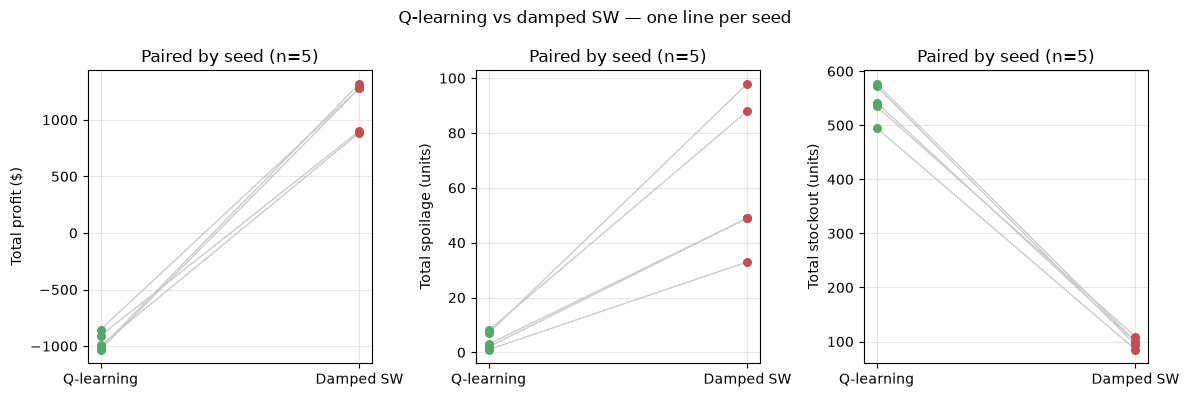

In [7]:
def _paired_metric_values(
    ql_rows: list[EpisodeTotals],
    sw_rows: list[EpisodeTotals],
    attr: str,
) -> tuple[list[float], list[float]]:
    return [getattr(row, attr) for row in ql_rows], [getattr(row, attr) for row in sw_rows]


BENCH_METRICS = [
    ("profit", "Total profit ($)"),
    ("waste", "Total spoilage (units)"),
    ("stockout", "Total stockout (units)"),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
x_positions = [0, 1]
for ax, (attr, ylab) in zip(axes, BENCH_METRICS, strict=True):
    ql_vals, sw_vals = _paired_metric_values(ql_results, sw_results, attr)
    for i in range(len(EVAL_SEEDS)):
        ax.plot(x_positions, [ql_vals[i], sw_vals[i]], color="0.8", lw=1, zorder=1)
        ax.scatter(
            x_positions[0], ql_vals[i], color=POLICY_COLORS["Q-learning"], s=30, zorder=2
        )
        ax.scatter(
            x_positions[1], sw_vals[i], color=POLICY_COLORS["Damped SW"], s=30, zorder=2
        )
    ax.set_xticks(x_positions)
    ax.set_xticklabels(["Q-learning", "Damped SW"])
    ax.set_ylabel(ylab)
    ax.set_title(f"Paired by seed (n={len(EVAL_SEEDS)})")
fig.suptitle("Q-learning vs damped SW — one line per seed")
fig.tight_layout()
plt.show()

### Fig 2 — paired deltas (Q-learning − damped SW)

Bar height is the per-seed difference. Positive profit bars favor Q-learning; lower
spoilage or stockout bars also favor Q-learning when the metric is a cost.

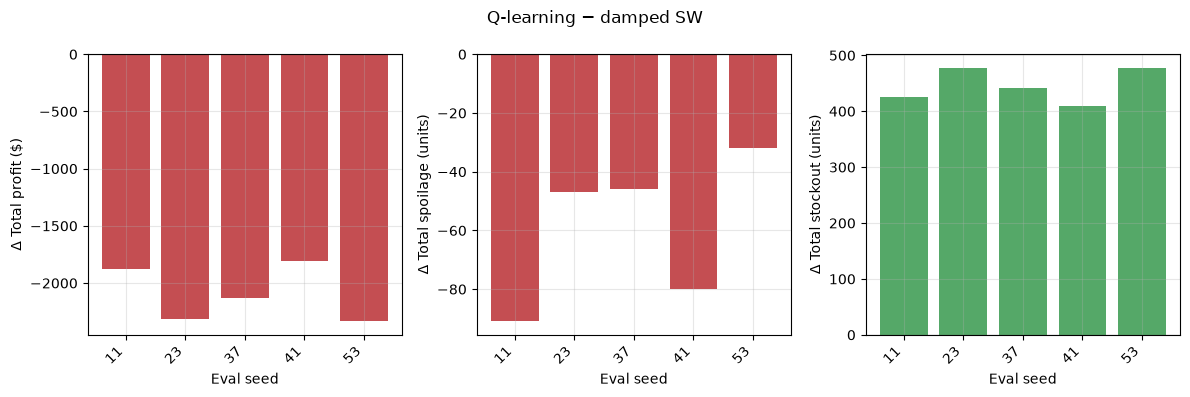

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (attr, ylab) in zip(axes, BENCH_METRICS, strict=True):
    deltas = [
        getattr(q_row, attr) - getattr(sw_row, attr)
        for q_row, sw_row in zip(ql_results, sw_results, strict=True)
    ]
    colors = ["#55A868" if delta >= 0 else "#C44E52" for delta in deltas]
    ax.bar(range(len(EVAL_SEEDS)), deltas, color=colors)
    ax.axhline(0, color="0.3", lw=0.8)
    ax.set_xticks(range(len(EVAL_SEEDS)))
    ax.set_xticklabels([str(seed) for seed in EVAL_SEEDS], rotation=45, ha="right")
    ax.set_ylabel(f"Δ {ylab}")
    ax.set_xlabel("Eval seed")
fig.suptitle("Q-learning − damped SW")
fig.tight_layout()
plt.show()

### Fig 3 — distribution across seeds (violins)

Violin width shows how each policy spreads over `EVAL_SEEDS`. Compare medians and
spread when choosing a deployment default.

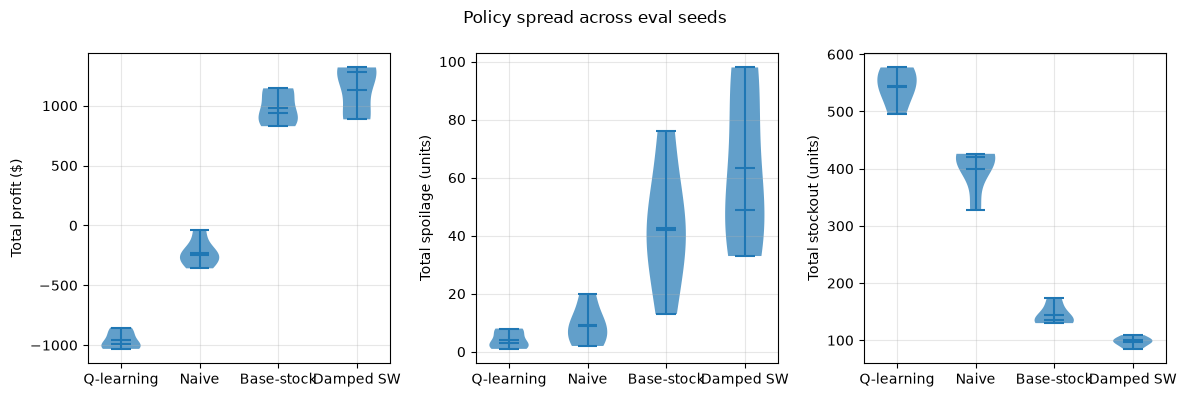

In [9]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (attr, ylab) in zip(axes, BENCH_METRICS, strict=True):
    data = [[getattr(row, attr) for row in policy_groups[name]] for name in policy_groups]
    parts = ax.violinplot(data, showmeans=True, showmedians=True)
    for body in parts["bodies"]:
        body.set_alpha(0.7)
    ax.set_xticks(np.arange(1, len(policy_groups) + 1))
    ax.set_xticklabels(list(policy_groups))
    ax.set_ylabel(ylab)
fig.suptitle("Policy spread across eval seeds")
fig.tight_layout()
plt.show()

### Fig 4 — distribution histograms (all three policies)

Overlaid histograms of episode totals from the benchmark loop above (no extra
simulation). Same palette as the paired and violin charts; `n=len(EVAL_SEEDS)` seeds
per policy.


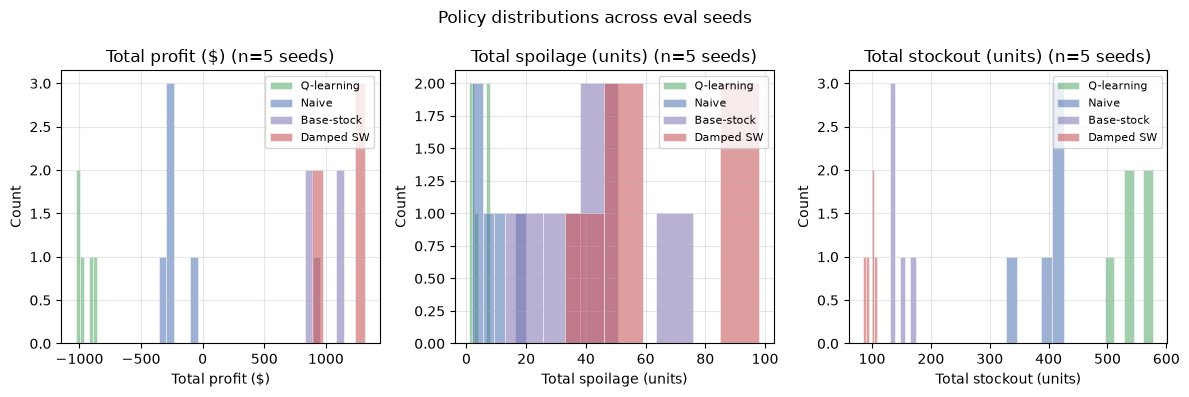

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (attr, ylab) in zip(axes, BENCH_METRICS, strict=True):
    for name, rows in policy_groups.items():
        values = [getattr(row, attr) for row in rows]
        ax.hist(
            values,
            bins=min(len(EVAL_SEEDS), 5),
            alpha=0.55,
            label=name,
            color=POLICY_COLORS[name],
            edgecolor="white",
            linewidth=0.6,
        )
    ax.set_ylabel("Count")
    ax.set_xlabel(ylab)
    ax.set_title(f"{ylab} (n={len(EVAL_SEEDS)} seeds)")
    ax.legend(fontsize=8)
fig.suptitle("Policy distributions across eval seeds")
fig.tight_layout()
plt.show()


## Cumulative profit (reuse benchmark daily logs)

Day-by-day cumulative profit for a **paired eval seed** — pulled from
`benchmark_daily` populated in the benchmark loop (no re-simulation).


In [11]:
eval_seed = EVAL_SEEDS[0]

naive_daily = benchmark_daily[("Naive", eval_seed)]
ql_daily = benchmark_daily[("Q-learning", eval_seed)]
eval_sw_daily = benchmark_daily[("Damped SW", eval_seed)]

print(f"Naive total profit (eval seed={eval_seed}): {sum(naive_daily):.1f}")
print(f"Q-learning total profit (eval seed={eval_seed}): {sum(ql_daily):.1f}")
print(f"Damped SW total profit (eval seed={eval_seed}): {sum(eval_sw_daily):.1f}")


Naive total profit (eval seed=11): -358.3
Q-learning total profit (eval seed=11): -993.1
Damped SW total profit (eval seed=11): 886.1


### Cumulative profit comparison

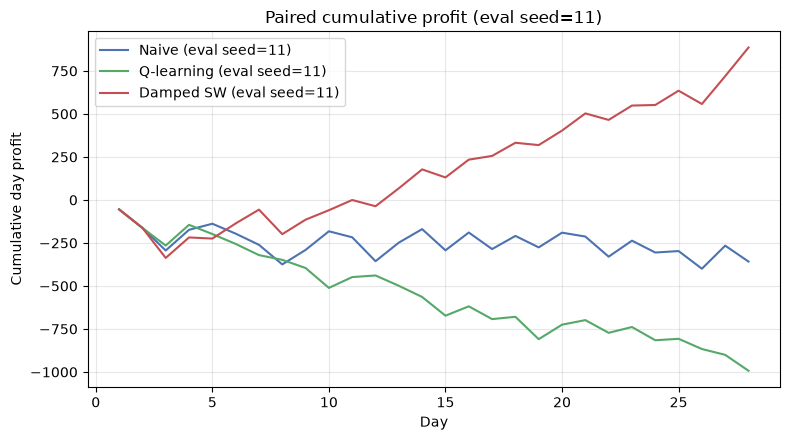

In [12]:
def cumulative(series: list[float]) -> list[float]:
    out: list[float] = []
    total = 0.0
    for x in series:
        total += x
        out.append(total)
    return out


fig, ax = plt.subplots()
days = list(range(1, len(naive_daily) + 1))
ax.plot(
    days,
    cumulative(naive_daily),
    label=f"Naive (eval seed={eval_seed})",
    color=POLICY_COLORS["Naive"],
)
ax.plot(
    days,
    cumulative(ql_daily),
    label=f"Q-learning (eval seed={eval_seed})",
    color=POLICY_COLORS["Q-learning"],
)
ax.plot(
    days,
    cumulative(eval_sw_daily),
    label=f"Damped SW (eval seed={eval_seed})",
    color=POLICY_COLORS["Damped SW"],
)
ax.set_xlabel("Day")
ax.set_ylabel("Cumulative day profit")
ax.set_title(f"Paired cumulative profit (eval seed={eval_seed})")
ax.legend()
fig.tight_layout()
plt.show()


### Mean profit across paired seeds

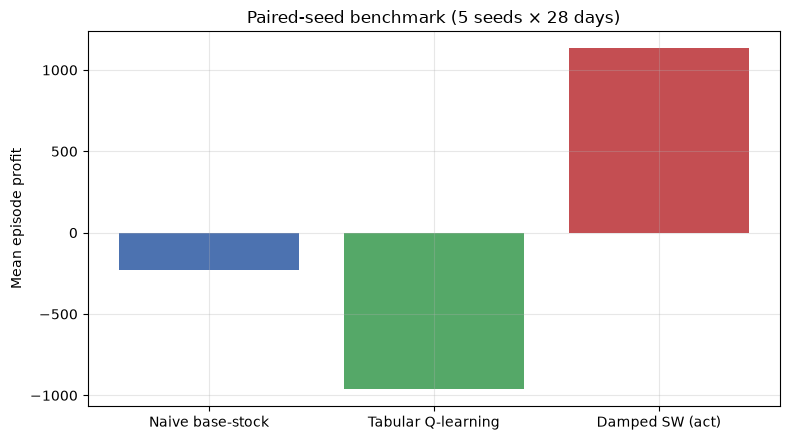

In [13]:
by_policy: dict[str, list[float]] = {
    "Naive base-stock": [row.profit for row in naive_results],
    "Tabular Q-learning": [row.profit for row in ql_results],
    "Damped SW (act)": [row.profit for row in sw_results],
}

labels = list(by_policy.keys())
means = [mean(by_policy[label]) for label in labels]
colors = [POLICY_COLORS["Naive"], POLICY_COLORS["Q-learning"], POLICY_COLORS["Damped SW"]]

fig, ax = plt.subplots()
ax.bar(labels, means, color=colors)
ax.set_ylabel("Mean episode profit")
ax.set_title(f"Paired-seed benchmark ({len(EVAL_SEEDS)} seeds × {N_DAYS} days)")
fig.tight_layout()
plt.show()

## Next steps

- Replace `TabularQLearningController` with your own `order(ctx)` implementation.
- Feed richer state from `ctx.belief` (f-marginals per lot) or `ctx.demand.dow_means`.
- Tune `BASE_STOCK_TARGET` or Q-learning actions against the same `run_controller_session` loop.
- Match Studio observation channels via `OBS_CODE_TYPE`, `OBS_SCAN_WASTE`, `OBS_DELIVERY_HISTORY`.
- Read ADR 0148 for why this path differs from `sim.episode.run_closed_loop_episode`.
